https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?tab=table

In [50]:
import pandas as pd

df = pd.read_csv("gdp-per-capita-worldbank-constant-usd.csv")

target_years = range(2010, 2011)  # Список лет от 2016 до 2020 включительно

# Фильтруем данные по списку лет, удаляем пропуски и переводим в массив
X = df[df["Year"].isin(target_years)]['GDP per capita'].dropna().astype(float).to_numpy()


In [51]:
X.shape

(223,)

### Описательная статистика выборки

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


data_raw = X.astype(float)
n_raw = data_raw.size
mean_raw = data_raw.mean()
median_raw = np.median(data_raw)
mode_rounded = np.round(data_raw / 100) * 100
mode_res = stats.mode(mode_rounded, keepdims=False)
mode_raw = float(mode_res.mode)
var_raw = np.var(data_raw, ddof=1)
std_raw = np.std(data_raw, ddof=1)
cv_raw = std_raw / mean_raw * 100

print(f'Объем выборки: {n_raw}')
print(f'Мода (по округлению до 100 USD): {mode_raw:,.2f}')
print(f'Медиана: {median_raw:,.2f}')
print(f'Среднее: {mean_raw:,.2f}')
print(f'Выборочная дисперсия: {var_raw:,.2f}')
print(f'Выборочное стандартное отклонение: {std_raw:,.2f}')
print(f'Коэффициент вариации: {cv_raw:.2f}%')
print('Оценка однородности:', 'выборка однородна' if cv_raw < 33 else 'выборка неоднородна')


def grouped_stats(sample, bins_count):
    sample = np.asarray(sample, dtype=float)
    counts, edges = np.histogram(sample, bins=bins_count)
    group_ids = np.digitize(sample, edges[1:-1], right=False)
    centers = (edges[:-1] + edges[1:]) / 2
    mean_value = sample.mean()
    total = np.sum((sample - mean_value) ** 2) / sample.size
    within = 0.0
    between = 0.0
    for idx in range(bins_count):
        group = sample[group_ids == idx]
        if group.size == 0:
            continue
        group_mean = group.mean()
        within += np.sum((group - group_mean) ** 2)
        between += group.size * (group_mean - mean_value) ** 2
    within /= sample.size
    between /= sample.size
    return {
        'counts': counts,
        'edges': edges,
        'centers': centers,
        'mean': mean_value,
        'total': total,
        'within': within,
        'between': between,
    }

Объем выборки: 223
Мода (по округлению до 100 USD): 1,200.00
Медиана: 5,616.09
Среднее: 15,409.60
Выборочная дисперсия: 475,327,008.57
Выборочное стандартное отклонение: 21,802.00
Коэффициент вариации: 141.48%
Оценка однородности: выборка неоднородна


### Удаление выбросов

In [53]:
q1 = np.percentile(data_raw, 25)
q3 = np.percentile(data_raw, 75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

mask = (data_raw >= lower_bound) & (data_raw <= upper_bound)
X_clean = data_raw[mask]
data = X_clean
n = data.size

print(f'Q1: {q1:,.2f}')
print(f'Q3: {q3:,.2f}')
print(f'IQR: {iqr:,.2f}')
print(f'Нижняя граница выбросов: {lower_bound:,.2f}')
print(f'Верхняя граница выбросов: {upper_bound:,.2f}')
print(f'Удалено выбросов: {n_raw - n}')
if n_raw - n:
    removed_values = np.sort(data_raw[~mask])
    print('Удаленные значения:', np.array2string(removed_values, precision=2, separator=', '))
else:
    print('Выбросы не обнаружены')

print(f'Размер очищенной выборки: {n}')

Q1: 2,083.72
Q3: 21,108.00
IQR: 19,024.28
Нижняя граница выбросов: -26,452.71
Верхняя граница выбросов: 49,644.43
Удалено выбросов: 15
Удаленные значения: [ 49672.7 ,  51209.45,  51440.08,  52555.77,  53768.35,  64722.98,
  70747.84,  72333.8 ,  72804.4 ,  74195.05,  79483.09,  81315.42,
 106544.05, 118382.91, 141814.78]
Размер очищенной выборки: 208


### Разбиение на интервалы, гистограмма и полигон

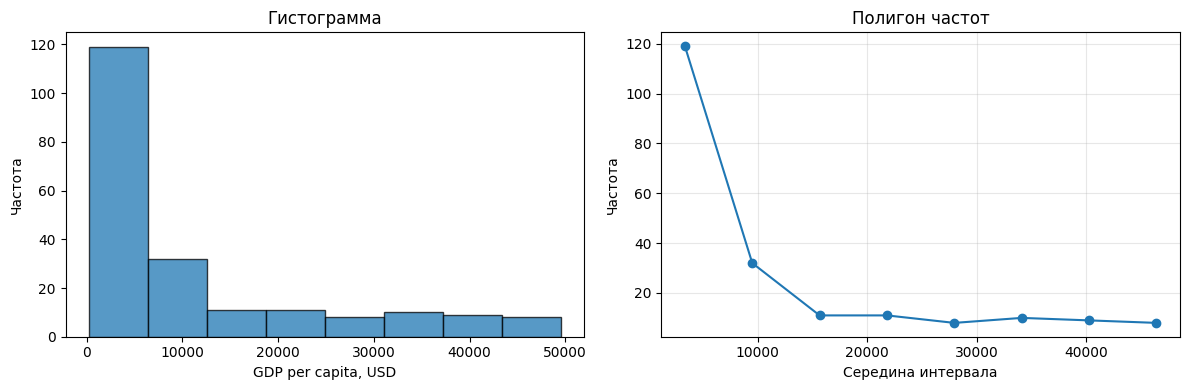

Число интервалов s = 8
По виду гистограммы и полигона распределение правосторонне асимметричное; разумная гипотеза — логнормальное распределение.
Среднее (очищенная выборка): 11,035.34
Дисперсия (по n): 173,639,597.91
Стандартное квадратическое отклонение (по n): 13,177.24


In [54]:
s = 1 + int(np.log2(n))
summary = grouped_stats(data, s)
counts = summary['counts']
edges = summary['edges']
centers = summary['centers']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data, bins=edges, edgecolor='black', alpha=0.75)
plt.title('Гистограмма')
plt.xlabel('GDP per capita, USD')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
plt.plot(centers, counts, marker='o')
plt.title('Полигон частот')
plt.xlabel('Середина интервала')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Число интервалов s = {s}')
print('По виду гистограммы и полигона распределение правосторонне асимметричное; разумная гипотеза — логнормальное распределение.')
print(f'Среднее (очищенная выборка): {summary["mean"]:,.2f}')
print(f'Дисперсия (по n): {np.var(data, ddof=0):,.2f}')
print(f'Стандартное квадратическое отклонение (по n): {np.std(data, ddof=0):,.2f}')

### Групповые дисперсии и правило сложения дисперсий

In [55]:
var_total = summary['total']
var_within = summary['within']
var_between = summary['between']
share_between = var_between / var_total
std_group = np.sqrt(var_total)

print(f'Общая дисперсия: {var_total:,.2f}')
print(f'Внутригрупповая дисперсия: {var_within:,.2f}')
print(f'Межгрупповая дисперсия: {var_between:,.2f}')
print(f'Проверка правила сложения дисперсий: {var_within + var_between:,.2f}')
print(f'Разность: {abs(var_total - (var_within + var_between)):.6f}')
print(f'Доля межгрупповой дисперсии: {share_between:.4f}')

Общая дисперсия: 173,639,597.91
Внутригрупповая дисперсия: 2,898,405.48
Межгрупповая дисперсия: 170,741,192.43
Проверка правила сложения дисперсий: 173,639,597.91
Разность: 0.000000
Доля межгрупповой дисперсии: 0.9833


### Сравнение разбиений s-1 и s+1

In [56]:
def share_for_bins(sample, bins_count):
    stats_data = grouped_stats(sample, bins_count)
    return stats_data['between'] / stats_data['total'], stats_data

s_minus = max(2, s - 1)
s_plus = s + 1
share_minus, stats_minus = share_for_bins(data, s_minus)
share_plus, stats_plus = share_for_bins(data, s_plus)

print(f's-1 = {s_minus}:')
print(f'  Межгрупповая дисперсия: {stats_minus["between"]:,.2f}')
print(f'  Внутригрупповая дисперсия: {stats_minus["within"]:,.2f}')
print(f'  Доля межгрупповой дисперсии: {share_minus:.4f}')
print(f's+1 = {s_plus}:')
print(f'  Межгрупповая дисперсия: {stats_plus["between"]:,.2f}')
print(f'  Внутригрупповая дисперсия: {stats_plus["within"]:,.2f}')
print(f'  Доля межгрупповой дисперсии: {share_plus:.4f}')

if share_plus > share_minus:
    print('Лучше разбиение на s+1 интервалов: оно сильнее выделяет межгрупповую вариацию.')
else:
    print('Лучше разбиение на s-1 интервалов: оно дает большую долю межгрупповой вариации.')

s-1 = 7:
  Межгрупповая дисперсия: 169,912,024.24
  Внутригрупповая дисперсия: 3,727,573.67
  Доля межгрупповой дисперсии: 0.9785
s+1 = 9:
  Межгрупповая дисперсия: 171,057,138.52
  Внутригрупповая дисперсия: 2,582,459.40
  Доля межгрупповой дисперсии: 0.9851
Лучше разбиение на s+1 интервалов: оно сильнее выделяет межгрупповую вариацию.


### Проверка закона распределения

In [57]:
mu_norm, sigma_norm = stats.norm.fit(data)
ks_norm = stats.kstest(data, 'norm', args=(mu_norm, sigma_norm))

shape_lognorm, loc_lognorm, scale_lognorm = stats.lognorm.fit(data, floc=0)
ks_lognorm = stats.kstest(data, 'lognorm', args=(shape_lognorm, loc_lognorm, scale_lognorm))

chi_bins = edges
observed = counts
expected = n * (
    stats.lognorm.cdf(chi_bins[1:], shape_lognorm, loc_lognorm, scale_lognorm)
    - stats.lognorm.cdf(chi_bins[:-1], shape_lognorm, loc_lognorm, scale_lognorm)
)
chi2_stat = np.sum((observed - expected) ** 2 / expected)
df_chi2 = len(observed) - 1 - 2
p_value_chi2 = stats.chi2.sf(chi2_stat, df_chi2)

print('Проверка гипотезы о логнормальном распределении:')
print(f'  KS для нормального распределения: D = {ks_norm.statistic:.4f}, p-value = {ks_norm.pvalue:.4f}')
print(f'  KS для логнормального распределения: D = {ks_lognorm.statistic:.4f}, p-value = {ks_lognorm.pvalue:.4f}')
print(f'  Параметры логнормального распределения: shape = {shape_lognorm:.4f}, scale = {scale_lognorm:,.2f}')
print(f'  Критерий Пирсона: chi2 = {chi2_stat:.4f}, df = {df_chi2}, p-value = {p_value_chi2:.4f}')

if ks_lognorm.pvalue > ks_norm.pvalue:
    print('По критерию Колмогорова логнормальная модель лучше нормальной.')
else:
    print('По критерию Колмогорова нормальная модель не хуже логнормальной.')

if p_value_chi2 < 0.05:
    print('По критерию Пирсона логнормальная гипотеза отвергается на уровне значимости 0.05.')
else:
    print('По критерию Пирсона логнормальная гипотеза не отвергается на уровне значимости 0.05.')

Проверка гипотезы о логнормальном распределении:
  KS для нормального распределения: D = 0.2222, p-value = 0.0000
  KS для логнормального распределения: D = 0.0654, p-value = 0.3217
  Параметры логнормального распределения: shape = 1.3499, scale = 5,024.63
  Критерий Пирсона: chi2 = 42.0105, df = 5, p-value = 0.0000
По критерию Колмогорова логнормальная модель лучше нормальной.
По критерию Пирсона логнормальная гипотеза отвергается на уровне значимости 0.05.
